In [1]:
# polynomial regression 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

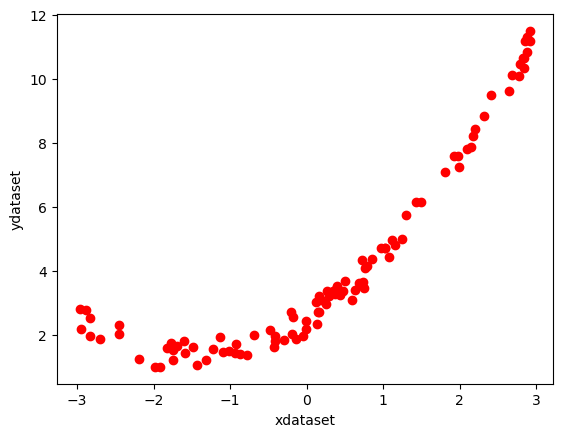

In [3]:
x = 6*np.random.rand(100,1)-3  # now value ranges from -3 to +3
y = 0.5 * x**2 + 1.5 * x + 2 + np.random.rand(100,1) # last part is our outlier

# scatter plot
plt.scatter(x,y,color='r')
plt.xlabel('xdataset')
plt.ylabel('ydataset')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# X: feature matrix, y: target vector
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [5]:
# standardization of data before given to model

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Compute mean/std and then transform
X_train = scaler.fit_transform(X_train) 
# Use training parameters to transform new data
X_test = scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train, y_train)


LinearRegression()

In [8]:
# cross val score
from sklearn.model_selection import cross_val_score
val_scores = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=5)

In [9]:
score = np.mean(val_scores)
score

np.float64(-2.5378567079972614)

In [10]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression.predict(X_test))


In [11]:

score  # 0.61->0.81

0.799208409322379

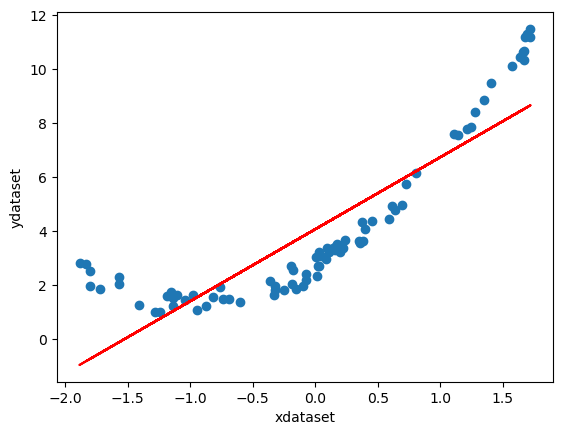

In [12]:
# what model predicted
plt.plot(X_train,regression.predict(X_train),color='r')
# actrual train data plot
plt.scatter(X_train,y_train)
plt.xlabel('xdataset')
plt.ylabel('ydataset')
plt.show()

# this contains many errors as it do not fit porperly so we use polynomail degree

In [13]:
# poynomial func
from sklearn.preprocessing import PolynomialFeatures

In [14]:
# now make poly instance that fit_tranform and tranform it x_train , x_test
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [15]:
# now train and predict score
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly,y_train)
score = r2_score(y_test, regression.predict(X_test_poly))
score

0.9893448640901849

In [16]:
print(regression.coef_)
# we got three values as we now using 2 degree polynomial equation so it gvies there coeffecients

[[0.         2.65892916 1.3449963 ]]


In [17]:
print(regression.intercept_)

[2.72475277]


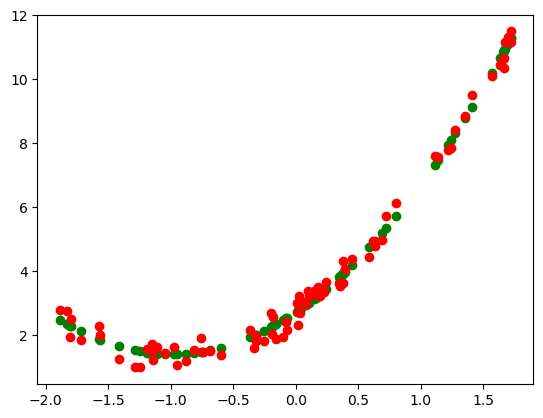

In [18]:
# visualization
plt.scatter(X_train,regression.predict(X_train_poly),color='g')
plt.scatter(X_train,y_train,color='r')
plt.show()

In [30]:

def poly_regression(degree):
    # Create smooth X values for curve
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    # Create pipeline (Polynomial + Linear Regression)
    poly_regression = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=True)),
        ("lin_reg", LinearRegression())
    ])
    
    # Train model
    poly_regression.fit(X_train, y_train)
    
    # Predict new values
    y_pred_new = poly_regression.predict(X_new)
    
    # Plot prediction curve
    plt.plot(X_new, y_pred_new, 'r', label="Degree " + str(degree), linewidth=2)
    
    # Plot training & test data
    plt.plot(X_train, y_train, 'b.', linewidth=3)
    plt.plot(X_test, y_test, 'g.', linewidth=3)
    
    # Labels and settings
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

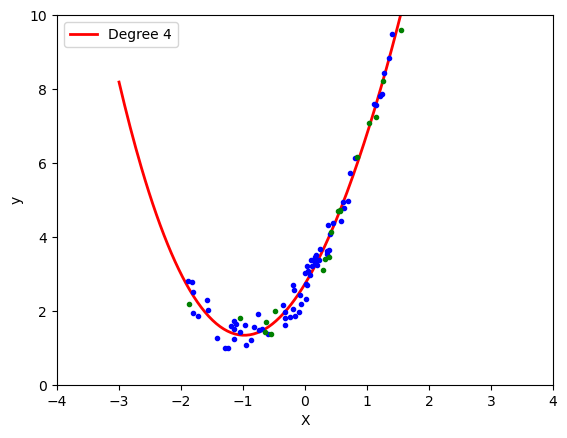

In [33]:
poly_regression(4)